In [21]:
from z3 import *
import numpy as np
import random
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()
import arviz as az
# our library
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload
import pickle as pkl
from datetime import datetime

project_root = os.path.abspath(os.path.join(os.getcwd(), "..",))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
import src.sat_metropolis.models as models
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)
reload(models)

<module 'src.sat_metropolis.models' from '/Users/efh/Desktop/6. semester/Bachelor/sat-metropolis-businessnisser/src/sat_metropolis/models.py'>

312
312

In [10]:
import os
import pickle

# num_cons = [2, 3, 4, 5, 6, 7]
# rfs = [4, 2, 1]
# ds = [1, 2, 3, 4, 5, 10]
# samples = [50, 100,500]



num_cons = [3]#[2, 3, 4, 5, 6, 7]#, 7]
rfs = [1]#, 2, 4]
ds = [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]
samples = 1000#[50, 100, 500, 1000, 3000, 7000]

backend = "pycmsgen"
runs = 1 # set to 0 to load existing results without running new experiments

results_path = "ResultsRoadsCmsgen.pkl"

if "Results" in globals():
    print("Using existing Results already in memory.")
elif os.path.exists(results_path):
    with open(results_path, "rb") as f:
        Results = pickle.load(f)
    print(f"Loaded existing results from {results_path}")
else:
    Results = {}
    print("No existing Results in memory or pickle file found. Starting fresh.")

for num_con in num_cons:
    if num_con not in Results:
        Results[num_con] = {}

    for reduction_factor in rfs:
        if reduction_factor not in Results[num_con]:
            Results[num_con][reduction_factor] = {}

        y = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143])

        num_bits = int(np.log2((y[:num_con] / reduction_factor).max())) + 1
        max_int_bits = max([
            int(np.log2((total / summands) + 1)) + 1
            for (summands, total) in zip(
                models.__gen_conf_matrix(np.array([1, 2, 3, 4, 5, 6, 7][:num_con])).sum(axis=1),
                (y[:num_con] / reduction_factor)
            )
        ])
        max_int_bv = 2**max_int_bits - 1

        (g, num_bits, num_vars) = models.get_roads_sat(
            num_bits=num_bits,
            max_int_bv=max_int_bv,
            num_con=num_con,
            y_reduction_factor=reduction_factor
        )

        for run in range(runs):
            if run not in Results[num_con][reduction_factor]:
                Results[num_con][reduction_factor][run] = {}

            for d in ds:
                if d not in Results[num_con][reduction_factor][run]:
                    Results[num_con][reduction_factor][run][d] = {}

                added_new = False

                for num_samples in samples:
                    if num_samples in Results[num_con][reduction_factor][run][d]:
                        print(
                            f"Skipping existing: con={num_con}, rf={reduction_factor}, "
                            f"run={run}, D={d}, samples={num_samples}"
                        )
                        continue

                    print(
                        f"Computing: con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}, samples={num_samples}"
                    )

                    trace = mcmc.sample_mh_trace_from_z3_model(
                        method="incremental",
                        backend=backend,
                        z3_problem=g,
                        D=d,
                        num_vars=num_vars,
                        num_bits=num_bits,
                        parallel_samples=1,
                        time_tracking=True,
                        num_samples=num_samples,
                        print_z3_model=False,
                        fast_start=True,
                        print_progress=True,
                        plotting=False
                    )

                    Results[num_con][reduction_factor][run][d][num_samples] = trace
                    added_new = True

                if added_new:
                    with open(results_path, "wb") as f:
                        pickle.dump(Results, f)
                    print(
                        f"Saved progress after con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}"
                    )

with open(results_path, "wb") as f:
    pickle.dump(Results, f)

print(f"All done. Results saved to {results_path}")

Using existing Results already in memory.
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


Exception ignored in: <function AstRef.__del__ at 0x10dc26b60>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/z3/z3.py", line 351, in __del__
    if self.ctx.ref() is not None and self.ast is not None and Z3_dec_ref is not None:
       ^^^^^^^^
AttributeError: 'BoolRef' object has no attribute 'ctx'


TypeError: 'int' object is not iterable

In [ ]:
import os
import pickle
import time
import numpy as np

# num_cons = [2, 3, 4, 5, 6, 7]
# rfs = [4, 2, 1]
# ds = [1, 2, 3, 4, 5, 10, 15, 20]
# samples = [50, 100, 500, 1000, 3000, 7000]


num_cons = [5]#[2, 3, 4, 5, 6, 7]#, 7]
rfs = [1]#, 2, 4]
ds = [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100,1000,1000000000]#,50000]
samples = [1000]#[50, 100, 500, 1000, 3000, 7000]

backend = "pycmsgen"
runs = 1
TIMEOUT = 1000000  # seconds
OVERWRITE = False
results_path = "ResultsRoadsCmsgen.pkl"

if "Results" in globals():
    print("Using existing Results already in memory.")
elif os.path.exists(results_path):
    with open(results_path, "rb") as f:
        Results = pickle.load(f)
    print(f"Loaded existing results from {results_path}")
else:
    Results = {}
    print("No existing Results in memory or pickle file found. Starting fresh.")

for num_con in num_cons:
    if num_con not in Results:
        Results[num_con] = {}

    for reduction_factor in rfs:
        if reduction_factor not in Results[num_con]:
            Results[num_con][reduction_factor] = {}

        y = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143])

        num_bits = int(np.log2((y[:num_con] / reduction_factor).max())) + 1
        max_int_bits = max([
            int(np.log2((total / summands) + 1)) + 1
            for (summands, total) in zip(
                models.__gen_conf_matrix(np.array([1, 2, 3, 4, 5, 6, 7][:num_con])).sum(axis=1),
                (y[:num_con] / reduction_factor)
            )
        ])
        max_int_bv = 2**max_int_bits - 1

        (g, num_bits, num_vars) = models.get_roads_sat(
            num_bits=num_bits,
            max_int_bv=max_int_bv,
            num_con=num_con,
            y_reduction_factor=reduction_factor
        )

        for run in range(runs):
            if run not in Results[num_con][reduction_factor]:
                Results[num_con][reduction_factor][run] = {}

            if "_timed_out_ds" not in Results[num_con][reduction_factor][run]:
                Results[num_con][reduction_factor][run]["_timed_out_ds"] = []
            elif isinstance(Results[num_con][reduction_factor][run]["_timed_out_ds"], set):
                Results[num_con][reduction_factor][run]["_timed_out_ds"] = list(
                    Results[num_con][reduction_factor][run]["_timed_out_ds"]
                )

            timed_out_ds = set(Results[num_con][reduction_factor][run]["_timed_out_ds"])

            for d in ds:
                if d in timed_out_ds:
                    print(
                        f"Skipping timed-out D: con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}"
                    )
                    continue

                if d not in Results[num_con][reduction_factor][run]:
                    Results[num_con][reduction_factor][run][d] = {}

                added_new = False

                for num_samples in samples:
                    if num_samples in Results[num_con][reduction_factor][run][d] and not OVERWRITE:
                        print(
                            f"Skipping existing: con={num_con}, rf={reduction_factor}, "
                            f"run={run}, D={d}, samples={num_samples}"
                        )
                        continue

                    if num_samples in Results[num_con][reduction_factor][run][d] and OVERWRITE:
                        print(
                            f"Overwriting existing: con={num_con}, rf={reduction_factor}, "
                            f"run={run}, D={d}, samples={num_samples}"
    )

                    print(
                        f"Computing: con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}, samples={num_samples}"
                    )
                    if d == 1000000000:
                        recompute_D = True
                    else:
                        recompute_D = False
                    
                    start = time.time()
                 
                    try:
                        trace = mcmc.sample_mh_trace_from_z3_model(
                            method="incremental",
                            backend=backend,
                            z3_problem=g,
                            D=d,
                            num_vars=num_vars,
                            num_bits=num_bits,
                            parallel_samples=1,
                            time_tracking=True,
                            num_samples=num_samples,
                            print_z3_model=False,
                            fast_start=True,
                            print_progress=True,
                            #estart_every=10,
                            plotting=False,
                            recompute_D=recompute_D
                        )
                    except Exception as e:
                        print(
                            f"Error for con={num_con}, rf={reduction_factor}, "
                            f"run={run}, D={d}, samples={num_samples}: {e}"
                        )
                        break

                    elapsed = time.time() - start

                    if elapsed > TIMEOUT:
                        print(
                            f"TIMEOUT exceeded ({elapsed:.2f}s > {TIMEOUT}s): "
                            f"con={num_con}, rf={reduction_factor}, run={run}, D={d}, "
                            f"samples={num_samples}. Marking D as timed out for this run."
                        )
                        timed_out_ds.add(d)
                        Results[num_con][reduction_factor][run]["_timed_out_ds"] = sorted(timed_out_ds)

                        with open(results_path, "wb") as f:
                            pickle.dump(Results, f)
                        break

                    Results[num_con][reduction_factor][run][d][num_samples] = trace
                    added_new = True

                if added_new:
                    Results[num_con][reduction_factor][run]["_timed_out_ds"] = sorted(timed_out_ds)
                    with open(results_path, "wb") as f:
                        pickle.dump(Results, f)
                    print(
                        f"Saved progress after con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}"
                    )

with open(results_path, "wb") as f:
    pickle.dump(Results, f)

print(f"All done. Results saved to {results_path}")

Using existing Results already in memory.
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
Skipping existing: con=5, rf=1, run=0, D=1, samples=1000
Skipping existing: con=5, rf=1, run=0, D=2, samples=1000
Skipping existing: con=5, rf=1, run=0, D=3, samples=1000
Skipping existing: con=5, rf=1, run=0, D=4, samples=1000
Skipping existing: con=5, rf=1, run=0, D=5, samples=1000
Skipping existing: con=5, rf=1, run=0, D=10, samples=1000
Skipping timed-out D: con=5, rf=1, run=0, D=15
Skipping timed-out D: con=5, rf=1, run=0, D=20
Skipping existing: con=5, rf=1, run=0, D=30, samples=1000
Skipping existing: con=5, rf=1, run=0, D=40, samples=1000
Skipping existing: con=5, rf=1, run=0, D=50, samples=1000
Skipping existing: con=5, rf=1, run=0, D=60, samples=1000
Skipping existing: con=5, rf=1, run=0, D=70, sa

[(1, 2), (1, 3), (2, 3)]
[(1, 2), (1, 3), (2, 3)]
[(1, 2), (1, 3), (2, 3)]
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
[(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
[(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
[(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]
[(1

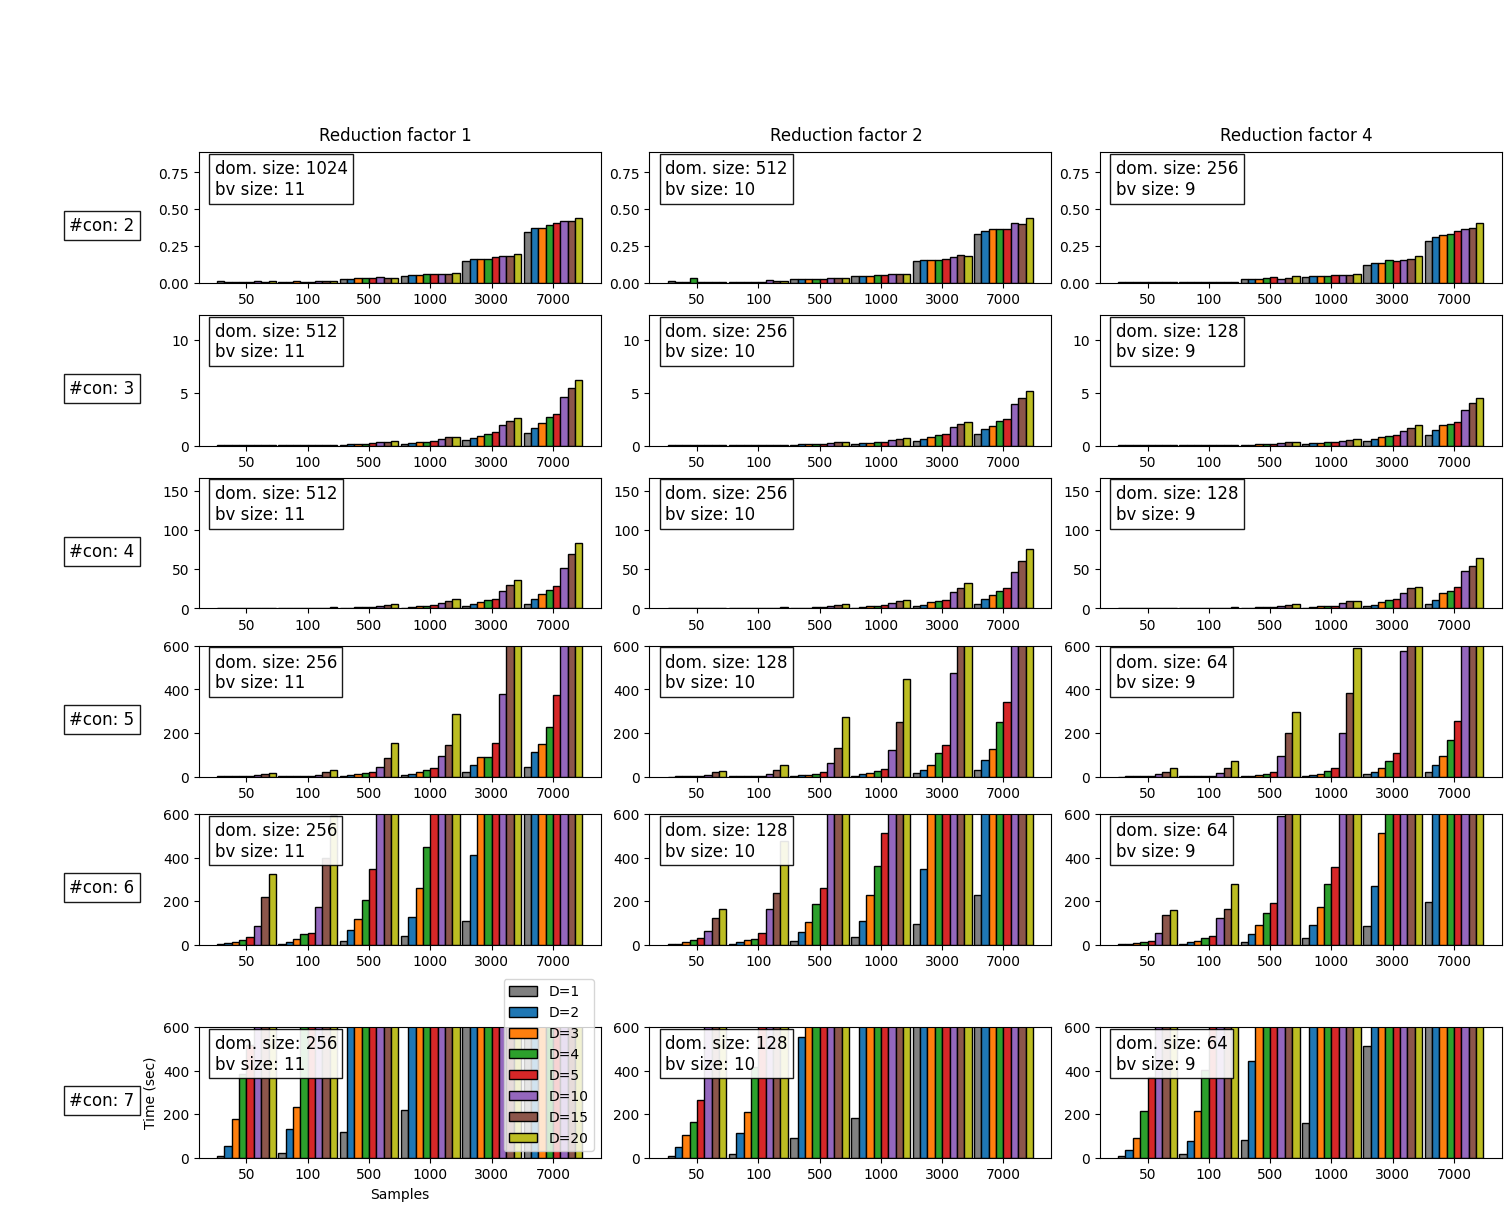

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_cons = [3]#[2, 3, 4, 5, 6, 7]#, 7]
rfs = [1]#, 2, 4]
ds = [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]
samples = 1000#[50, 100, 500, 1000, 3000, 7000]
round_to = 0.100


flexible_y = True   # if True, each row gets its own y-scale ceiling
default_ylim = 610
missing_time = 610

fig, axs = plt.subplots(
    len(num_cons) + 1, 
    len(rfs) + 1,
    figsize=(15, 12),
    layout='constrained',
    width_ratios=np.concatenate([[1], np.repeat(4, len(rfs))])
)

axs[0, 0].set_axis_off()

for i, c in enumerate(num_cons):
    axs[i + 1, 0].text(
        0.59, 0.4,
        f'#con: {c}',
        bbox=dict(facecolor='white', alpha=0.9),
        fontsize=12
    )
    axs[i + 1, 0].axis('off')

for j, r in enumerate(rfs):
    axs[0, j + 1].text(0.3, 0, f'Reduction factor {r}', fontsize=12)
    axs[0, j + 1].axis('off')

colors = {
    1: '#808080',   # gray
    2: '#1F77B4',   # blue
    3: '#FF7F0E',   # orange
    4: '#2CA02C',   # green
    5: '#D62728',   # red
    10: '#9467BD',  # purple
    15: '#8C564B',  # brown
    20: '#BCBD22'   # olive
}

# Precompute all subplot values so row scaling can be determined first
plot_vals = {}
row_maxes = {}

for c in num_cons:
    row_max = 0

    for r in rfs:
        vals_for_subplot = {}

        for d in ds:
            means = []

            for s in samples:
                total_times = []

                if c in Results and r in Results[c]:
                    for run in Results[c][r]:
                        if d in Results[c][r][run] and s in Results[c][r][run][d]:
                            trace = Results[c][r][run][d][s]
                            total_times.append(np.sum(trace[1]))

                if len(total_times) == 0:
                    means.append(missing_time)
                else:
                    means.append(np.mean(total_times))

            vals_for_subplot[d] = means
            row_max = max(row_max, max(means))

        plot_vals[(c, r)] = vals_for_subplot
    
    row_maxes[c] = row_max

for i, c in enumerate(num_cons):
    if flexible_y:
        row_ylim = min(row_maxes[c] * 2, 600)
        row_ylim = max(row_ylim, 0.2)
    else:
        row_ylim = default_ylim

    for j, r in enumerate(rfs):
        ax = axs[i + 1, j + 1]

        x = np.arange(len(samples))
        width = 0.12

        for k, d in enumerate(ds):
            means = plot_vals[(c, r)][d]
            offset = width * k

            ax.bar(
                x + offset,
                means,
                width,
                label=f'D={d}',
                color=colors.get(d, '#808080'),
                edgecolor='black'
            )

        ax.set_xticks(x + width * (len(ds) - 1) / 2, samples)
        ax.set_ylim(0, row_ylim)

        y = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143])
        num_bits = int(np.log2((y[:c] / r).max())) + 1
        max_int_bits = max([
            int(np.log2((total / summands) + 1)) + 1
            for (summands, total) in zip(
                models.__gen_conf_matrix(np.array([1, 2, 3, 4, 5, 6, 7][:c])).sum(axis=1),
                (y[:c] / r)
            )
        ])
        max_int_bv = 2**max_int_bits - 1

        text_y = 0.68 * row_ylim
        ax.text(
            -0.1,
            text_y,
            f'dom. size: {max_int_bv + 1}\nbv size: {num_bits}',
            bbox=dict(facecolor='white', alpha=0.9),
            fontsize=12
        )

        if i == len(num_cons) - 1 and j == 0:
            ax.set_ylabel('Time (sec)')
            ax.set_xlabel('Samples')
            ax.legend(loc='lower right', ncols=1)

plt.show()

[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
Finding initial sample with Z3...
Z3 found initial sample in 0.10 seconds: {'x0': 246, 'x1': 233, 'x2': 186, 'x3': 139, 'x4': 255, 'x5': 27, 'x6': 6, 'x7': 1, 'x8': 130, 'x9': 62, 'x10': 0, 'x11': 255, 'x12': 128, 'x13': 250, 'x14': 253}, starting incremental sampling from there.
sample 10
sample 20
sample 30
sample 40
sample 50
sample 60
sample 70
sample 80
sample 90
sample 100
Restarting CMSGen solver at sample 100
Updated per-variable D: [2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1]
sample 110
sample 120
sample 130
sample 140
sample 150
sample 160
sample 170
sample 180
sample 190
sample 200
Restarting CMSGen solver at sample 200
Updated per-variable D: [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1]
sample 210
sample 220
sample 230
sample 240
sample 250
sample 260
sample 270
sample 280
sample 290
sample 300
Restarting CMSGen solver at sample 300
Updated per-variable

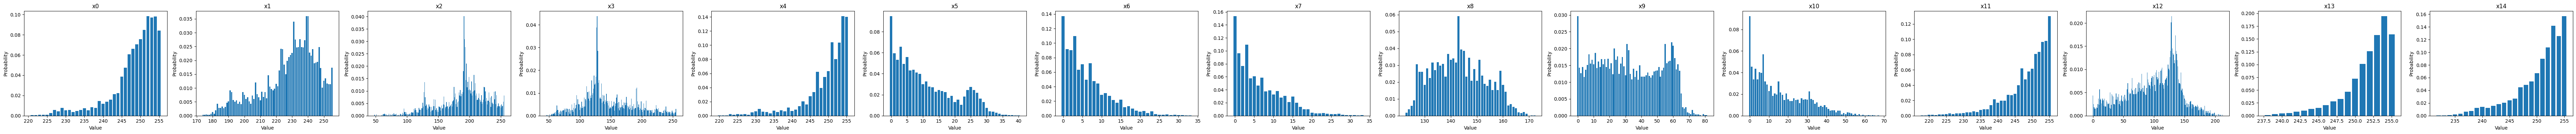

In [9]:
num_con = 5 #4
reduction_factor = 1
num_bits = 11
max_int_bv = 2**8-1

(g, num_bits, num_vars) = models.get_roads_sat(num_bits = num_bits,
                                               max_int_bv = max_int_bv,
                                               num_con=num_con,
                                               y_reduction_factor=reduction_factor)


trace=mcmc.sample_mh_trace_from_z3_model(
    method='incremental',
    backend='pycmsgen',
    z3_problem=g,
    D=1,
    num_vars=num_vars,
    num_bits=num_bits,
    parallel_samples=1,
    num_samples=6000,
    print_z3_model=False,
    restart_every=100,
    fast_start=True,
    recompute_D=True,
    escape_stagnant_ranges=True,
    stagnant_range_steps=100
)


array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x10'}>],
       [<Axes: title={'center': 'x11'}>, <Axes: title={'center': 'x11'}>],
       [<Axes: title={'center': 'x12'}>, <Axes: title={'center': 'x12'}>],
       [<Axes: title={'center': 'x13'}>, <Axe

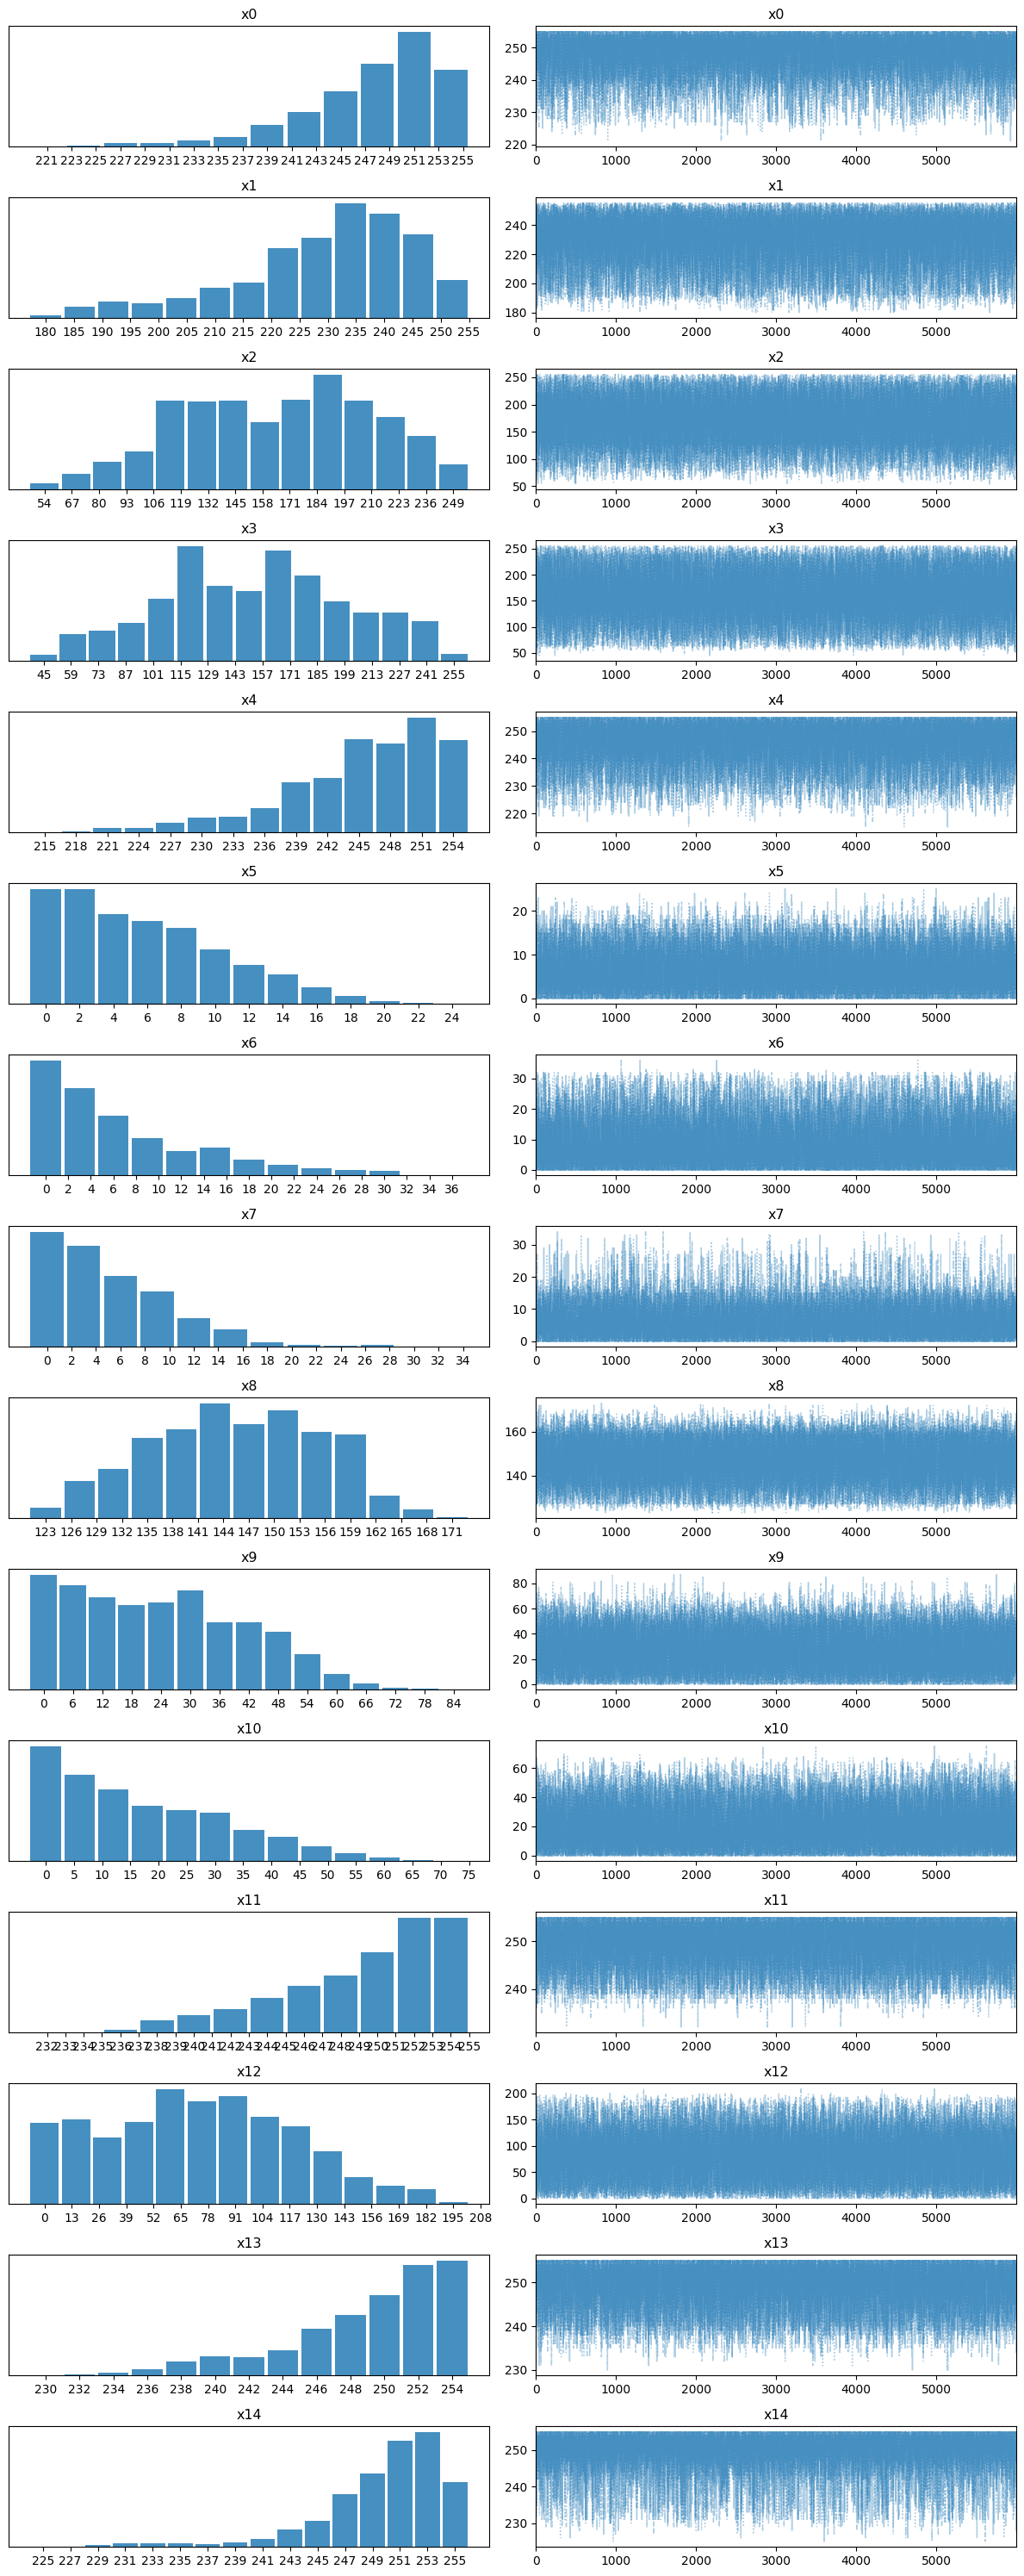

In [8]:
#plot trace
az.plot_trace(trace)

In [72]:
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

trace=Results[5][1][0][10][3000][0]

def trace_hist_gif_first_n(trace, n=3, filename="trace_hist_first_n.gif",
                           max_samples=500, fps=30, bins=30):
    """
    Animated histogram GIF for first n posterior parameters.
    The bar that receives the newest sample turns red for that frame.
    """

    idata = az.convert_to_inference_data(trace)
    var_names = list(idata.posterior.data_vars)[:n]

    if not var_names:
        raise ValueError("No posterior variables found in trace.")

    samples = {}
    hist_ranges = {}
    ymaxs = {}

    for var in var_names:
        arr = idata.posterior[var].values.reshape(-1)
        if max_samples is not None:
            arr = arr[:max_samples]
        samples[var] = arr

    min_len = min(len(v) for v in samples.values())

    # precompute ranges and max heights so axes stay fixed
    for var in var_names:
        x = samples[var][:min_len]
        xmin, xmax = x.min(), x.max()
        if xmin == xmax:
            xmin -= 0.5
            xmax += 0.5
        hist_ranges[var] = (xmin, xmax)

        counts, edges = np.histogram(x, bins=bins, range=(xmin, xmax))
        ymaxs[var] = max(counts.max(), 1)

    fig, axes = plt.subplots(len(var_names), 1, figsize=(8, 3 * len(var_names)), squeeze=False)
    axes = axes.ravel()

    bars_dict = {}
    edges_dict = {}

    # initialize empty bars
    for ax, var in zip(axes, var_names):
        xmin, xmax = hist_ranges[var]
        counts, edges = np.histogram([], bins=bins, range=(xmin, xmax))
        widths = np.diff(edges)

        bars = ax.bar(edges[:-1], counts, width=widths, align='edge')
        for bar in bars:
            bar.set_facecolor("C0")

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0, ymaxs[var] * 1.1)
        ax.set_title(var)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")

        bars_dict[var] = bars
        edges_dict[var] = edges

    def update(i):
        artists = []

        for ax, var in zip(axes, var_names):
            x = samples[var][:i+1]
            xmin, xmax = hist_ranges[var]
            edges = edges_dict[var]
            bars = bars_dict[var]

            counts, _ = np.histogram(x, bins=bins, range=(xmin, xmax))

            # reset all bars
            for j, bar in enumerate(bars):
                bar.set_height(counts[j])
                bar.set_facecolor("C0")

            # find bin for newest sample and color it red
            newest = samples[var][i]
            bin_idx = np.searchsorted(edges, newest, side="right") - 1
            bin_idx = np.clip(bin_idx, 0, bins - 1)
            bars[bin_idx].set_facecolor("red")

            ax.set_title(f"{var} | samples shown: {i+1}")
            artists.extend(bars)

        return artists

    anim = FuncAnimation(
        fig,
        update,
        frames=min_len,
        interval=1000 / fps,
        blit=False
    )

    plt.tight_layout()
    anim.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return filename

trace_hist_gif_first_n(trace, n=4, filename="trace_hist_first_4_d10.gif", max_samples=1500)

'trace_hist_first_4_d10.gif'

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x10'}>],
       [<Axes: title={'center': 'x11'}>, <Axes: title={'center': 'x11'}>],
       [<Axes: title={'center': 'x12'}>, <Axes: title={'center': 'x12'}>],
       [<Axes: title={'center': 'x13'}>, <Axe

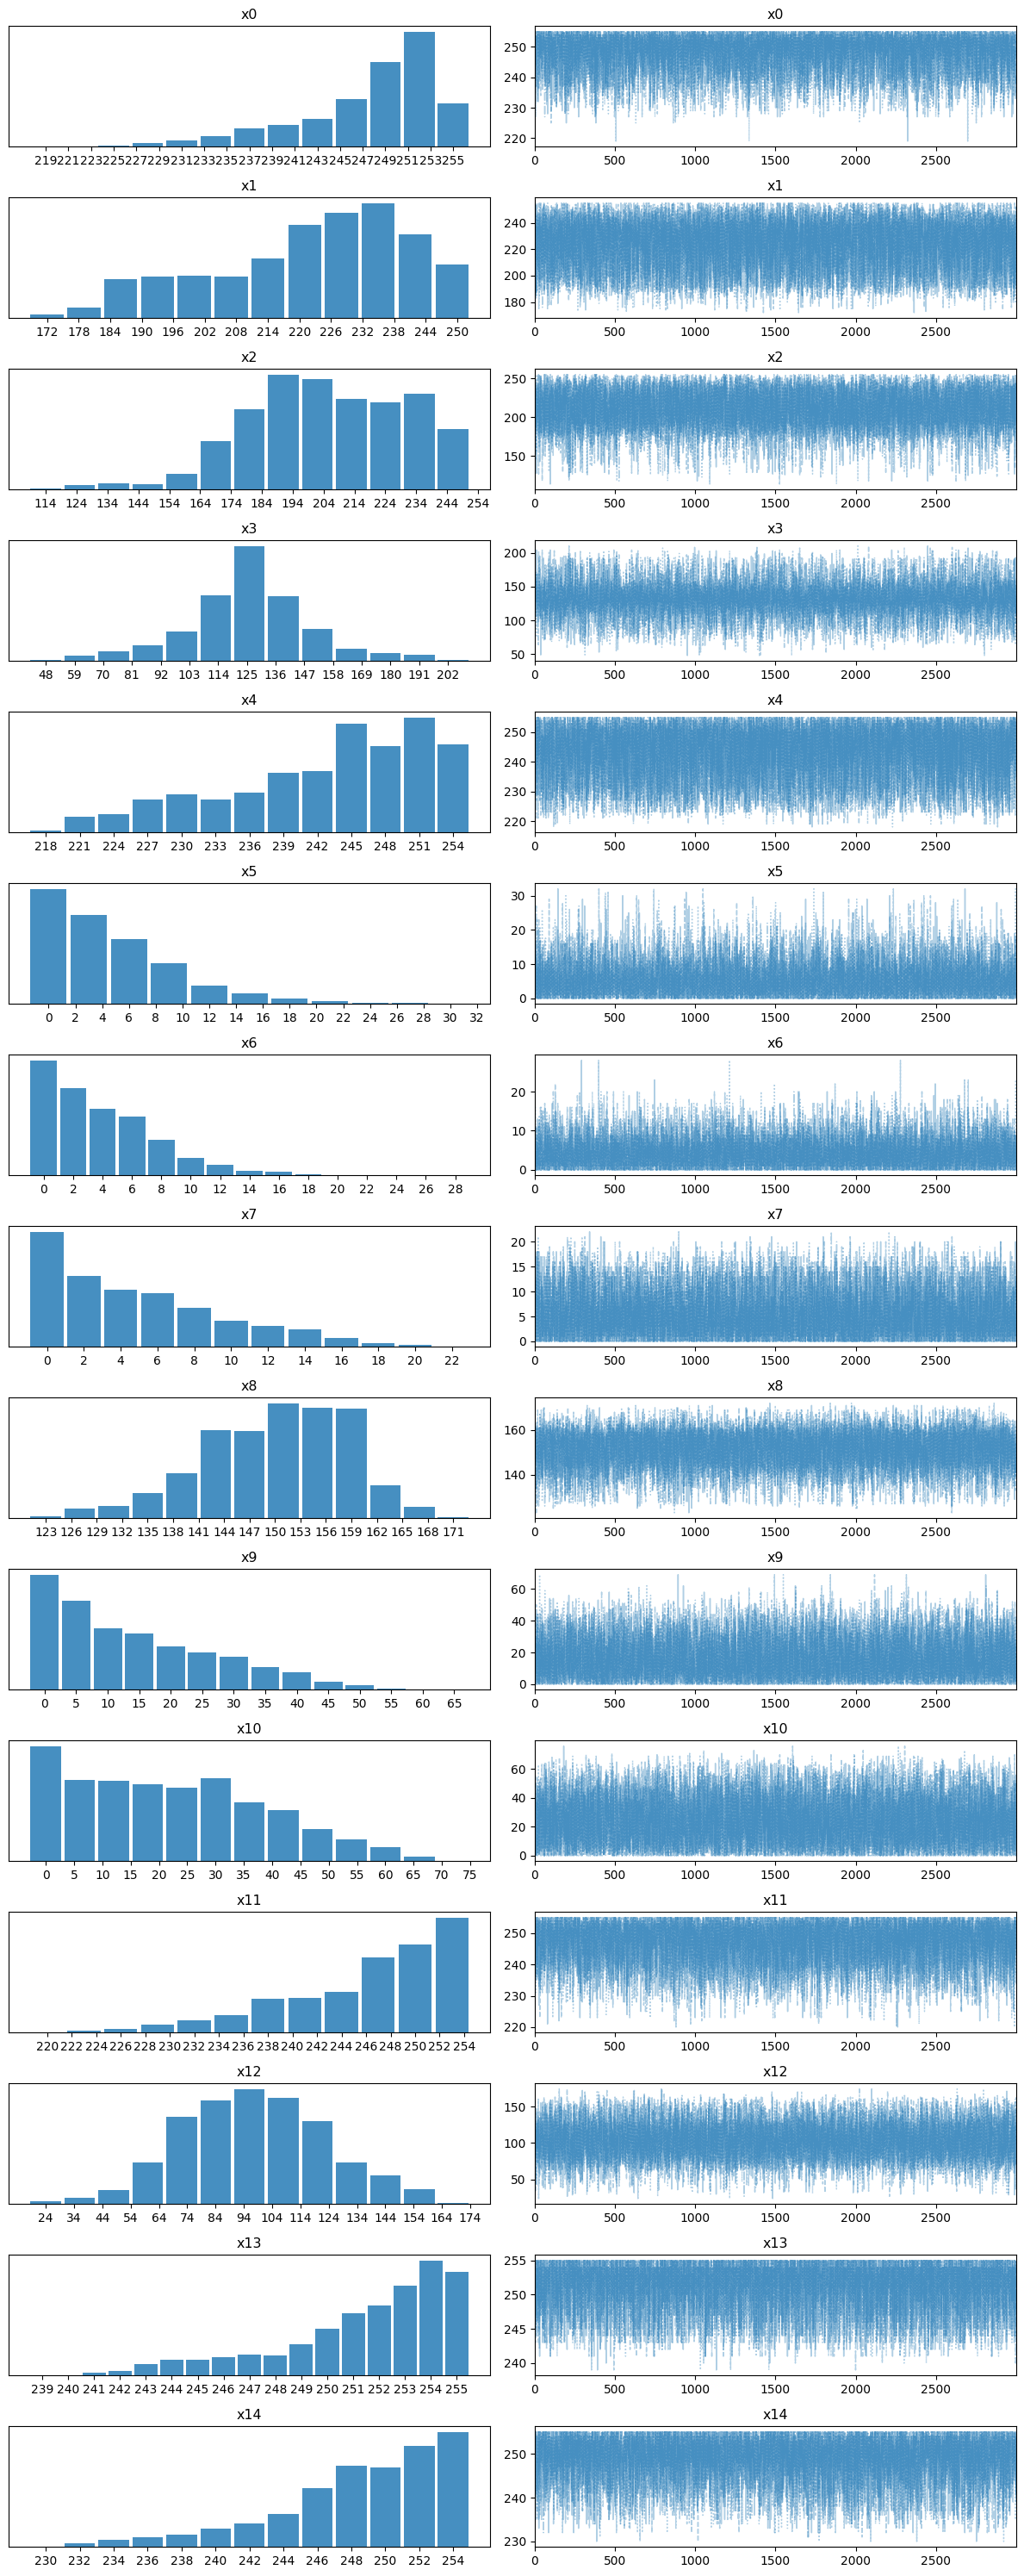

In [69]:
az.plot_trace(trace)

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x10'}>],
       [<Axes: title={'center': 'x11'}>, <Axes: title={'center': 'x11'}>],
       [<Axes: title={'center': 'x12'}>, <Axes: title={'center': 'x12'}>],
       [<Axes: title={'center': 'x13'}>, <Axe

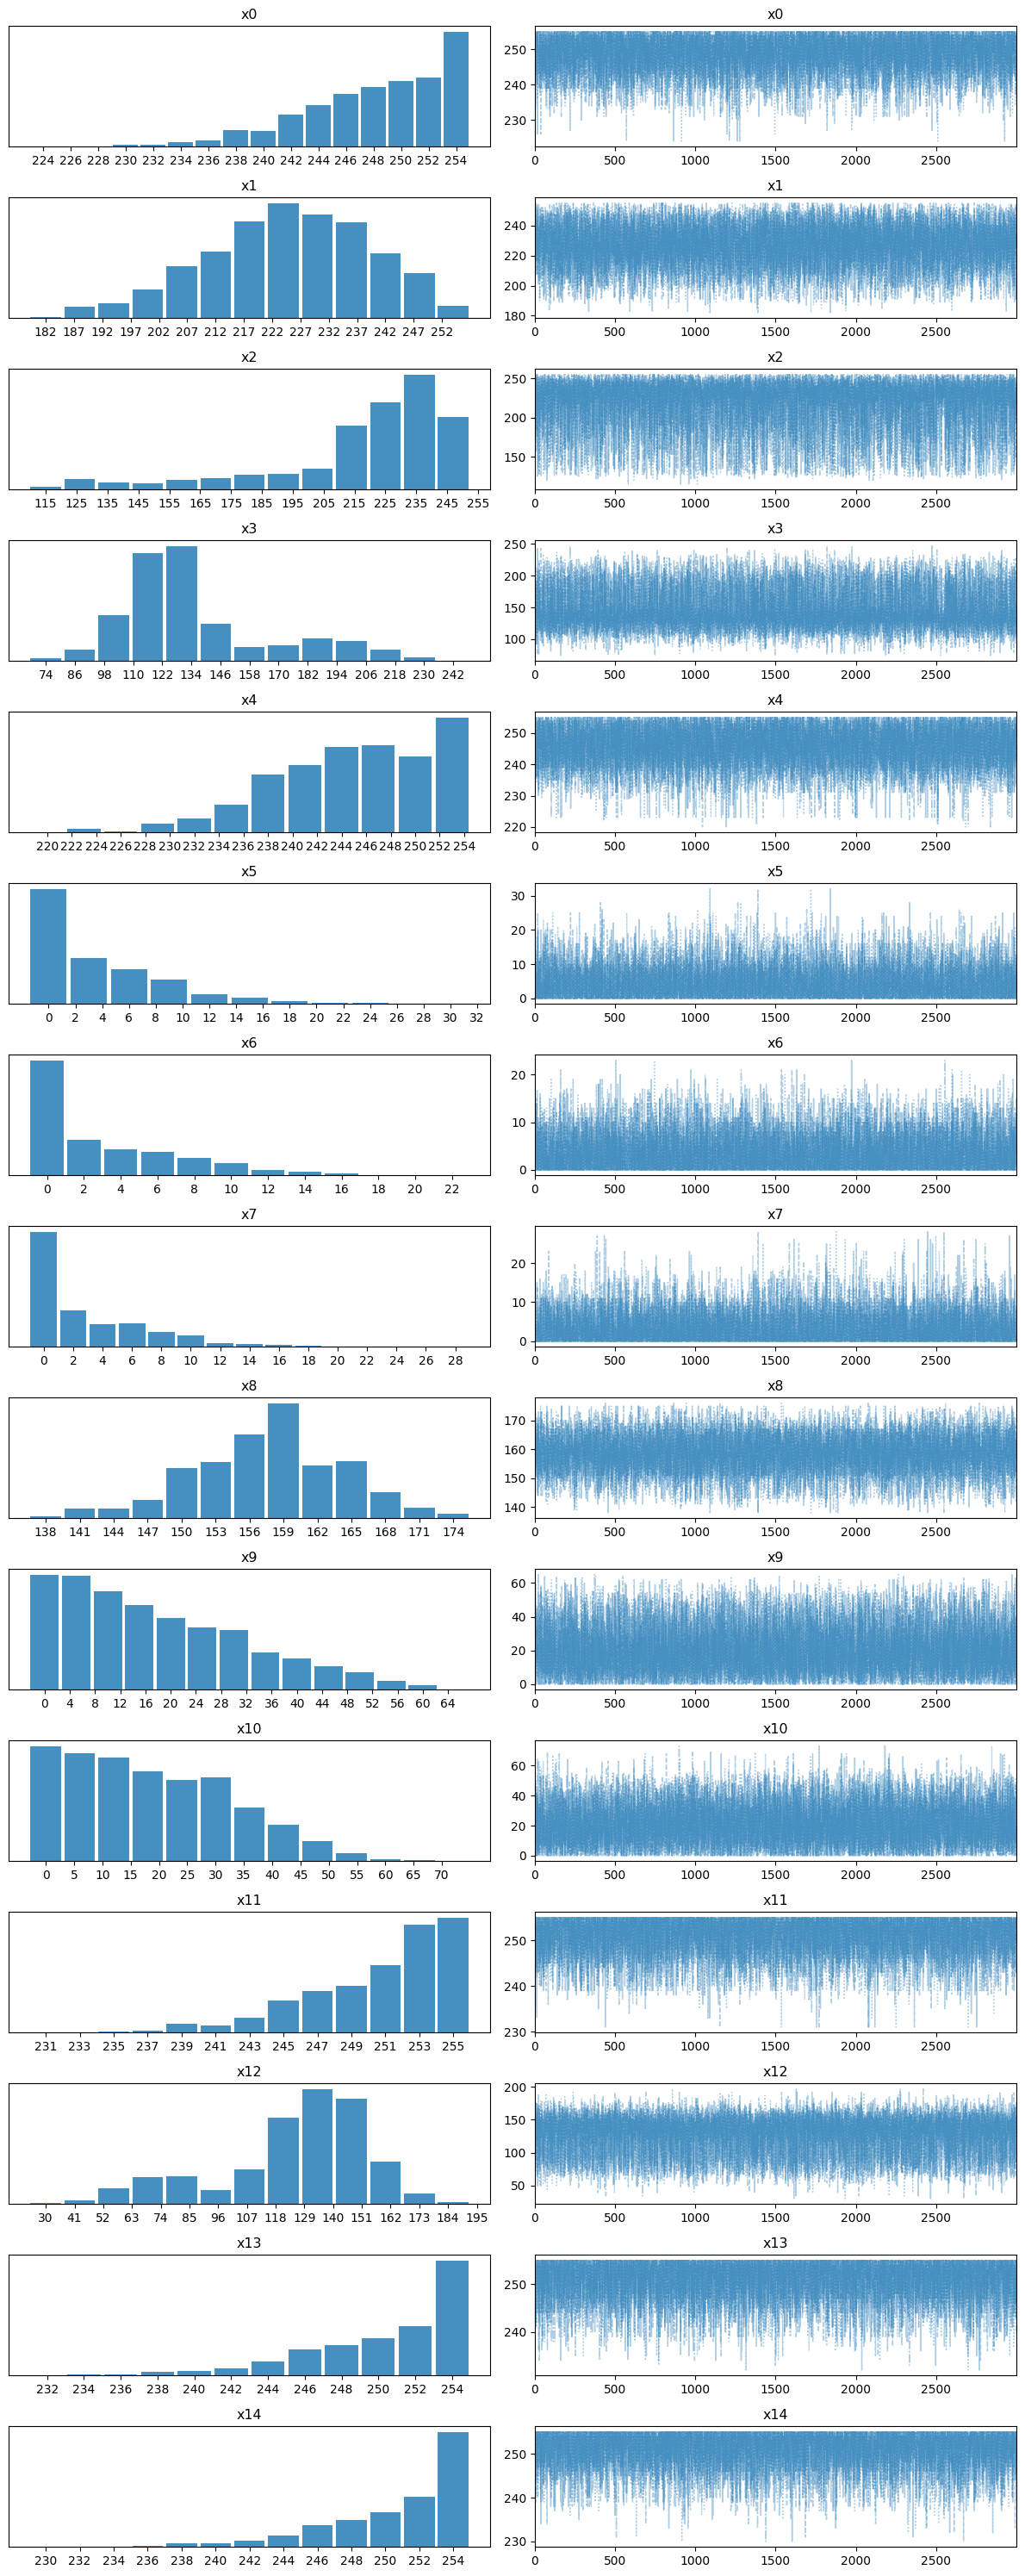

In [63]:
trace=Results[5][1][0][10][3000][0]
az.plot_trace(trace)

[(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
Finding initial sample with Z3...
Z3 found initial sample in 0.02 seconds: {'x0': 253, 'x1': 90, 'x2': 1, 'x3': 185, 'x4': 8, 'x5': 1, 'x6': 203, 'x7': 1, 'x8': 126, 'x9': 65}, starting incremental sampling from there.
sample 10
sample 20
sample 30
sample 40
sample 50
sample 60
sample 70
sample 80
sample 90
sample 100
Restarting CMSGen solver at sample 100
Updated per-variable D: [21, 28, 23, 30, 19, 15, 22, 20, 28, 19]
sample 110
sample 120
sample 130
sample 140
sample 150
sample 160
sample 170
sample 180
sample 190
sample 200
Restarting CMSGen solver at sample 200
Updated per-variable D: [17, 26, 20, 26, 17, 12, 18, 21, 25, 22]
sample 210
sample 220
sample 230
sample 240
sample 250
sample 260
sample 270
sample 280
sample 290
sample 300
Restarting CMSGen solver at sample 300
Updated per-variable D: [17, 23, 19, 25, 16, 11, 18, 19, 23, 21]
sample 310
sample 320
sample 330
sample 340
sample 350
sample 360
s

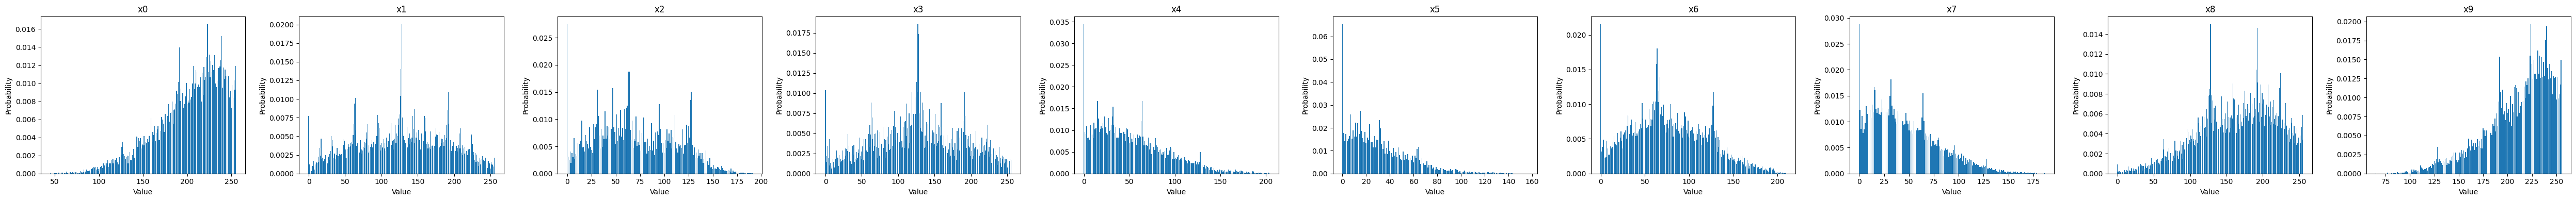

In [ ]:
num_con = 4
reduction_factor = 2
num_bits = 10
max_int_bv = 2**8-1

(g, num_bits, num_vars) = models.get_roads_sat(num_bits = num_bits,
                                               max_int_bv = max_int_bv,
                                               num_con=num_con,
                                               y_reduction_factor=reduction_factor)


trace=mcmc.sample_mh_trace_from_z3_model(
    method='incremental',
    backend='pycmsgen',
    z3_problem=g,
    D=10,
    num_vars=num_vars,
    num_bits=num_bits,
    parallel_samples=1,
    num_samples=20000,
    print_z3_model=False,
    restart_every=100,
    fast_start=True,
)


In [55]:
num_con = 5
reduction_factor = 1
num_bits = 11
max_int_bv = 2**9-1

(g, num_bits, num_vars) = models.get_roads_sat(num_bits = num_bits,
                                               max_int_bv = max_int_bv,
                                               num_con=num_con,
                                               y_reduction_factor=reduction_factor)


trace=mcmc.sample_mh_trace_from_z3_model(
    method='incremental',
    backend='pycmsgen',
    z3_problem=g,
    D=100,
    num_vars=num_vars,
    num_bits=num_bits,
    parallel_samples=1,
    num_samples=5000,
    print_z3_model=False,
    restart_every=100,
    fast_start=True,
)


[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 3), (2, 4), (2, 5), (2, 6), (3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
Finding initial sample with Z3...
Z3 found initial sample in 0.07 seconds: {'x0': 371, 'x1': 476, 'x2': 54, 'x3': 12, 'x4': 146, 'x5': 164, 'x6': 1, 'x7': 8, 'x8': 116, 'x9': 256, 'x10': 422, 'x11': 19, 'x12': 69, 'x13': 366, 'x14': 496}, starting incremental sampling from there.
sample 10
sample 20
sample 30
sample 40
sample 50
sample 60
sample 70
sample 80
sample 90
sample 100
Restarting CMSGen solver at sample 100
Updated per-variable D: [37, 62, 48, 41, 46, 34, 27, 21, 29, 41, 42, 48, 40, 46, 40]
sample 110
sample 120
sample 130
sample 140
sample 150
sample 160
sample 170
sample 180
sample 190
sample 200
Restarting CMSGen solver at sample 200
Updated per-variable D: [43, 57, 49, 39, 69, 35, 29, 18, 30, 33, 33, 46, 39, 45, 44]
sample 210
sample 220
sample 230
sample 240
sample 250
sample 260
sample 270
sample 280
sample 290
sample 300
Restarting CMSGen solver at s

KeyboardInterrupt: 

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>]],
      dtype=object)

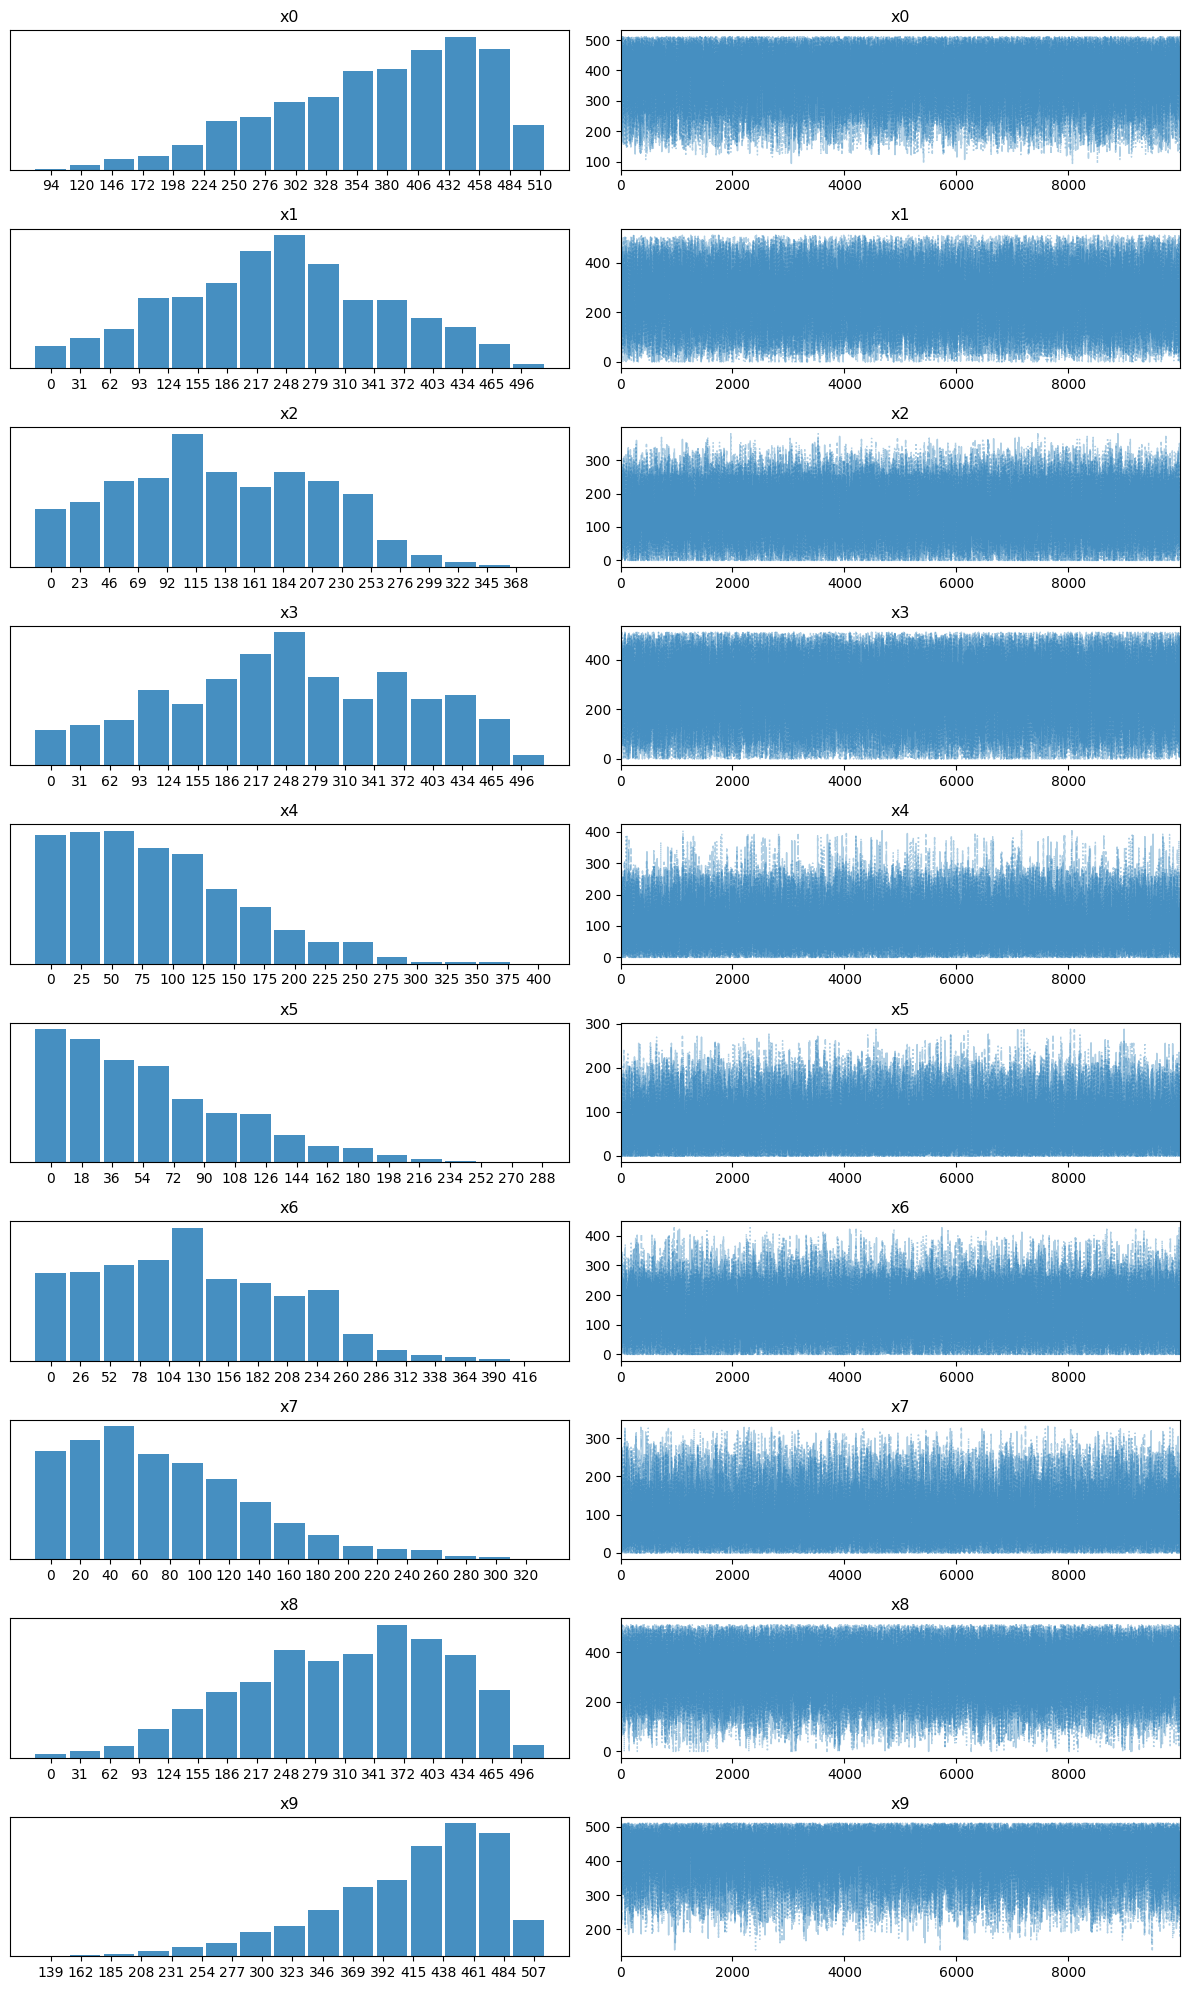

In [34]:
az.plot_trace(trace)

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
Finding initial sample with Z3...
Z3 found initial sample in 0.01 seconds: {'x0': 41, 'x1': 485, 'x2': 3, 'x3': 0, 'x4': 0, 'x5': 514}, starting incremental sampling from there.
sample 10
sample 20
sample 30
sample 40
sample 50
sample 60
sample 70
sample 80
sample 90
sample 100
Restarting CMSGen solver at sample 100
Updated per-variable D: [45, 70, 42, 26, 44, 70]
sample 110
sample 120
sample 130
sample 140
sample 150
sample 160
sample 170
sample 180
sample 190
sample 200
Restarting CMSGen solver at sample 200
Updated per-variable D: [58, 60, 37, 20, 55, 59]
sample 210
sample 220
sample 230
sample 240
sample 250
sample 260
sample 270
sample 280
sample 290
sample 300
Restarting CMSGen solver at sample 300
Updated per-variable D: [56, 52, 38, 18, 54, 50]
sample 310
sample 320
sample 330
sample 340
sample 350
sample 360
sample 370
sample 380
sample 390
sample 400
Restarting CMSGen solver at sample 400
Updated per-variable D: [51, 46, 36, 23

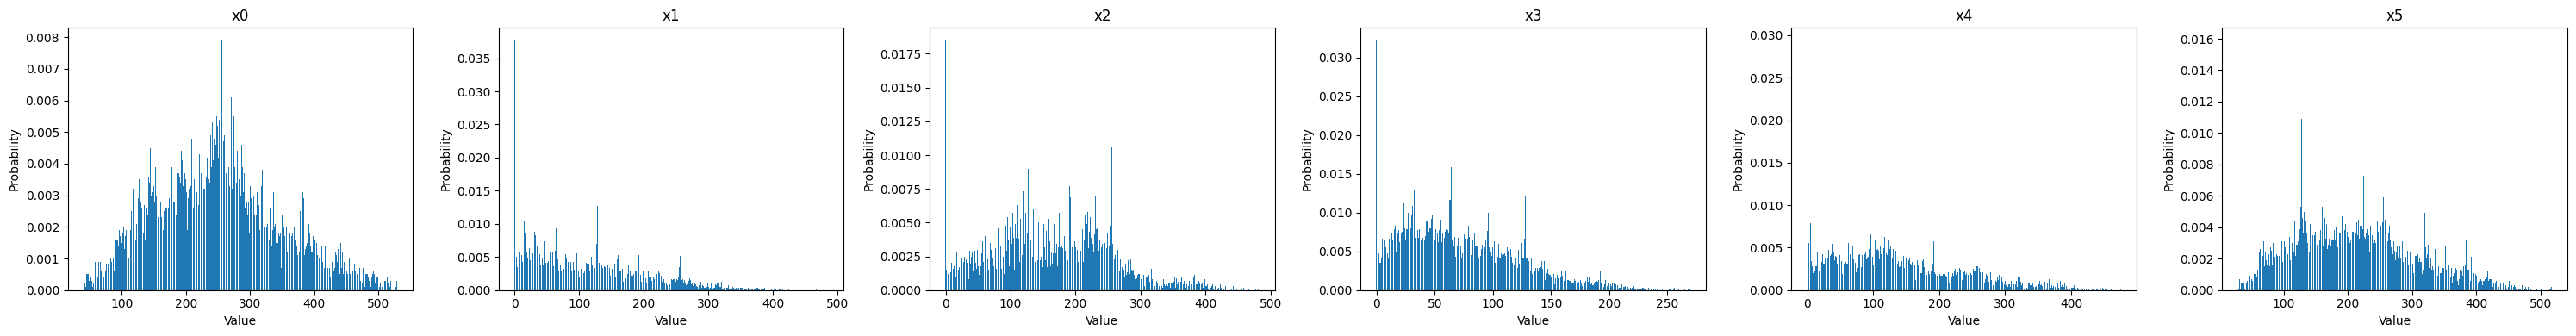

In [35]:
num_con = 3
reduction_factor = 2
num_bits = 11
max_int_bv = 2**10-1

(g, num_bits, num_vars) = models.get_roads_sat(num_bits = num_bits,
                                               max_int_bv = max_int_bv,
                                               num_con=num_con,
                                               y_reduction_factor=reduction_factor)


trace=mcmc.sample_mh_trace_from_z3_model(
    method='incremental',
    backend='pycmsgen',
    z3_problem=g,
    D=100,
    num_vars=num_vars,
    num_bits=num_bits,
    parallel_samples=1,
    num_samples=10000,
    print_z3_model=False,
    restart_every=100,
    fast_start=True,
)


array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>]],
      dtype=object)

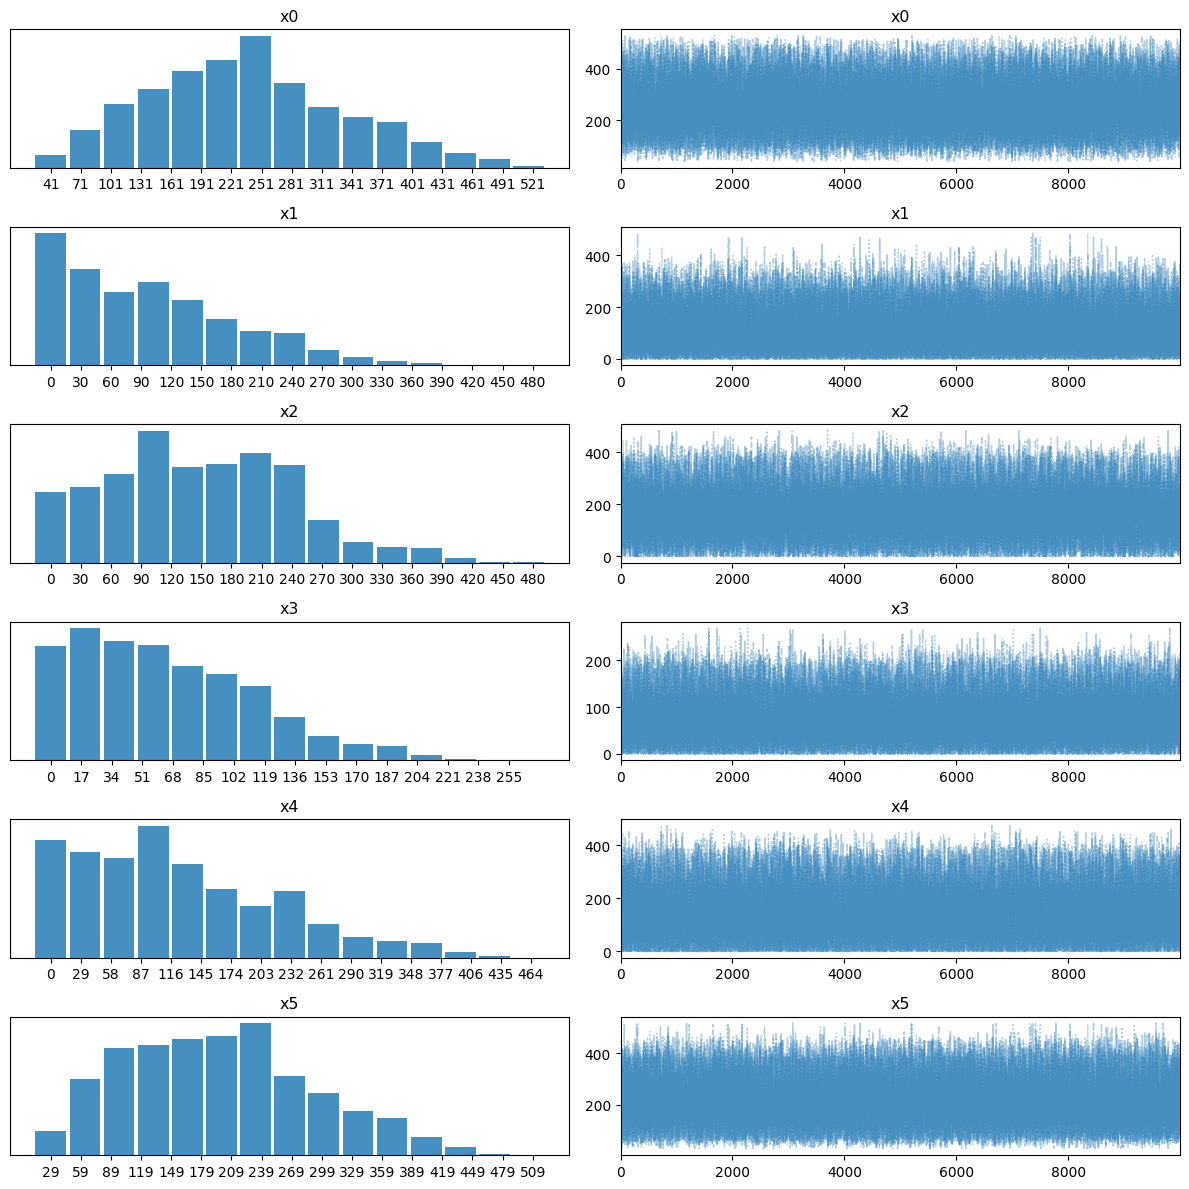

In [36]:
az.plot_trace(trace)

In [ ]:
#save trace as pkl file
#with open('traceroad1300d1.pkl', 'wb') as f:
#    pickle.dump(trace, f)

In [60]:
import pandas as pd

# Put all variables into one DataFrame: rows = samples, columns = variables
samples_df = pd.DataFrame({
    var: trace.posterior[var].values.flatten()
    for var in trace.posterior.data_vars
})

# Count most common joint samples across all variables
top_10 = (
    samples_df
    .value_counts()
    .reset_index(name="count")
    .head(10)
)

print(top_10)

    x0   x1   x2   x3   x4   x5  count
0  919   31  109  259  578  347     12
1  917   40  102  259  576  356     12
2  571  255  233  200  289  512     12
3  919   31  109  263  574  351     12
4  915   31  113  260  573  348     12
5  220  388  451   10  128  455     12
6  920   32  107  263  575  352     12
7  377  365  317   36  259  458      8
8  925   43   91  740  103  840      8
9  175  141  743   93    0  291      8


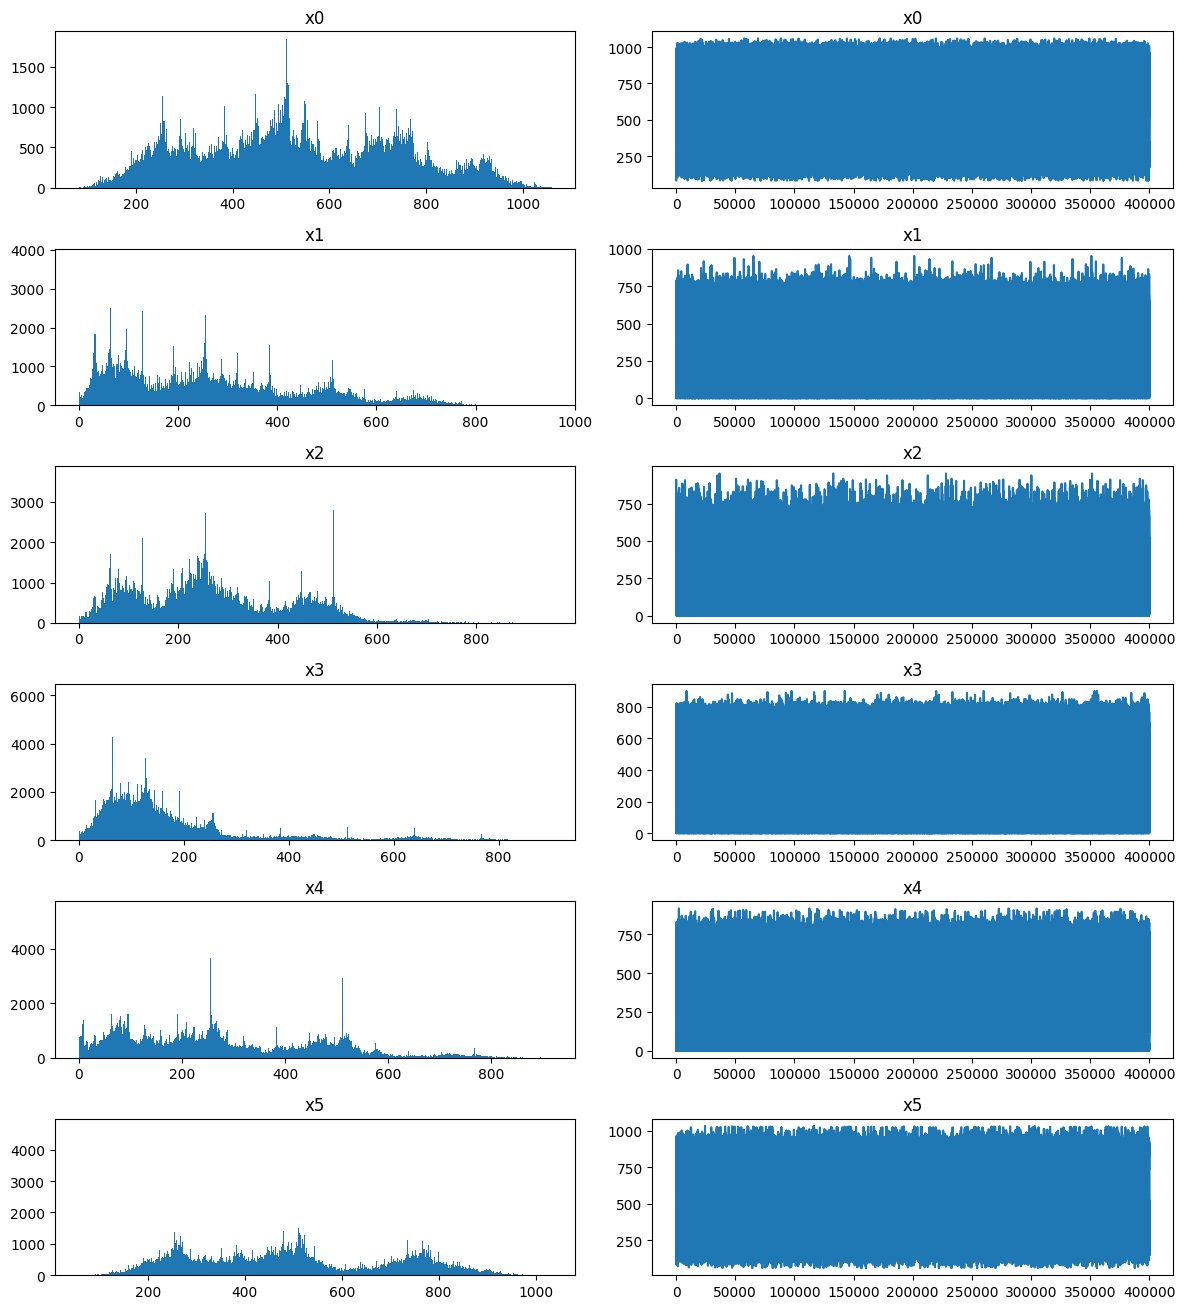

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

vars_ = list(trace.posterior.data_vars)

fig, axes = plt.subplots(
    len(vars_), 2,
    figsize=(12, 2.2 * len(vars_)),
    squeeze=False
)

for i, var in enumerate(vars_):
    vals = trace.posterior[var].values.flatten()
    
    bins = np.arange(
        np.floor(vals.min()) - 0.5,
        np.ceil(vals.max()) + 1.5,
        1
    )

    axes[i, 0].hist(vals, bins=bins)
    axes[i, 0].set_title(var)

    axes[i, 1].plot(vals)
    axes[i, 1].set_title(var)

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>]],
      dtype=object)

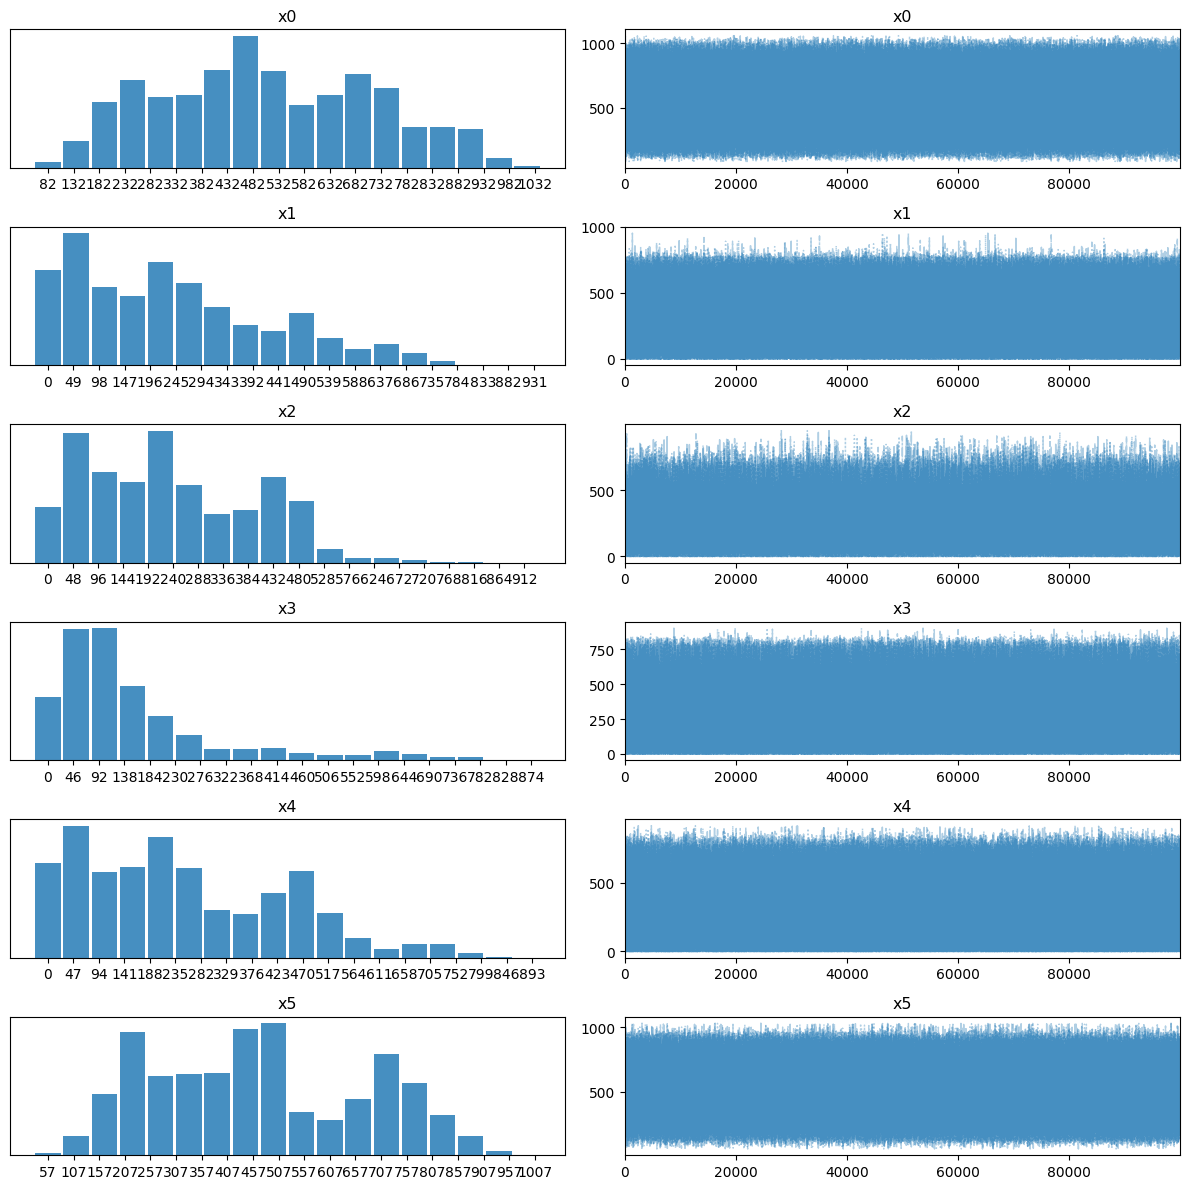

In [62]:
az.plot_trace(trace)

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>]],
      dtype=object)

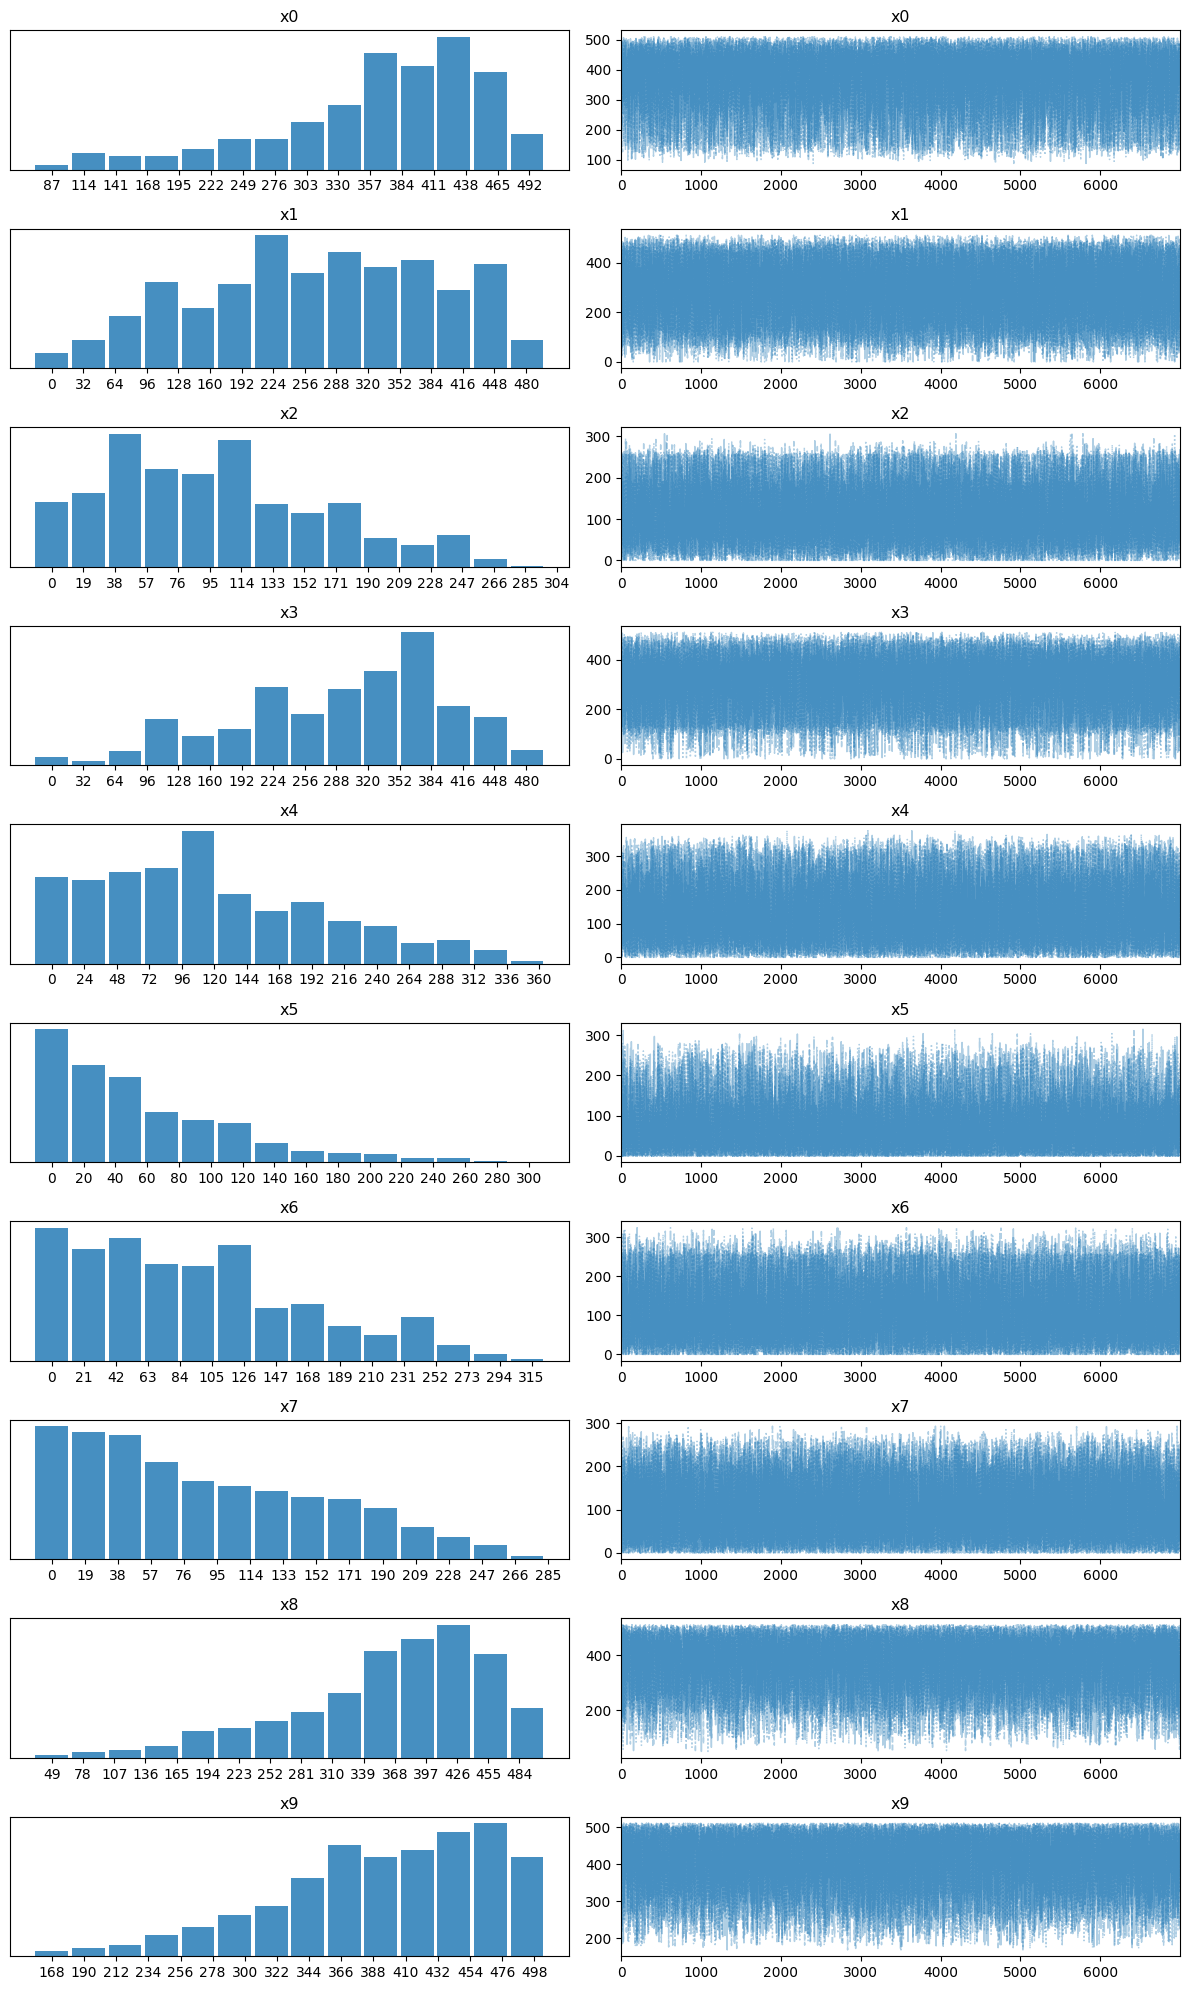

In [37]:
mean_dict = az.summary(trace[0])["mean"].to_dict()
print(list(mean_dict.values()))

x=list(mean_dict.values())

[241.829, 242.207, 78.554, 230.705, 57.409, 43.651, 192.645, 48.628, 69.814, 6.58, 7.648, 20.299, 9.86, 29.898, 73.224, 8.429, 31.582, 207.702, 110.861, 12.798, 7.598, 183.009, 156.803, 72.813, 145.754, 10.322, 225.765, 178.265]


In [ ]:
import os
import pickle

num_cons = [7]
rfs = [1]
ds = [2, 3, 4, 5, 10]
samples = [5000]
backend = "pycmsgen"
runs = 2 # set to 0 to load existing results without running new experiments

results_path = "ResultsRoadsCmsgenLongrun.pkl"

if "Results" in globals():
    print("Using existing Results already in memory.")
elif os.path.exists(results_path):
    with open(results_path, "rb") as f:
        Results = pickle.load(f)
    print(f"Loaded existing results from {results_path}")
else:
    Results = {}
    print("No existing Results in memory or pickle file found. Starting fresh.")

for num_con in num_cons:
    if num_con not in Results:
        Results[num_con] = {}

    for reduction_factor in rfs:
        if reduction_factor not in Results[num_con]:
            Results[num_con][reduction_factor] = {}

        y = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143])

        num_bits = int(np.log2((y[:num_con] / reduction_factor).max())) + 1
        max_int_bits = max([
            int(np.log2((total / summands) + 1)) + 1
            for (summands, total) in zip(
                models.__gen_conf_matrix(np.array([1, 2, 3, 4, 5, 6, 7][:num_con])).sum(axis=1),
                (y[:num_con] / reduction_factor)
            )
        ])
        max_int_bv = 2**max_int_bits - 1

        (g, num_bits, num_vars) = models.get_roads_sat(
            num_bits=num_bits,
            max_int_bv=max_int_bv,
            num_con=num_con,
            y_reduction_factor=reduction_factor
        )

        for run in range(runs):
            if run not in Results[num_con][reduction_factor]:
                Results[num_con][reduction_factor][run] = {}

            for d in ds:
                if d not in Results[num_con][reduction_factor][run]:
                    Results[num_con][reduction_factor][run][d] = {}

                added_new = False

                for num_samples in samples:
                    if num_samples in Results[num_con][reduction_factor][run][d]:
                        print(
                            f"Skipping existing: con={num_con}, rf={reduction_factor}, "
                            f"run={run}, D={d}, samples={num_samples}"
                        )
                        continue

                    print(
                        f"Computing: con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}, samples={num_samples}"
                    )

                    trace = mcmc.sample_mh_trace_from_z3_model(
                        method="incremental",
                        backend=backend,
                        z3_problem=g,
                        D=d,
                        num_vars=num_vars,
                        num_bits=num_bits,
                        parallel_samples=1,
                        time_tracking=True,
                        num_samples=num_samples,
                        print_z3_model=False,
                        fast_start=True,
                        print_progress=True,
                        plotting=False
                    )

                    Results[num_con][reduction_factor][run][d][num_samples] = trace
                    added_new = True

                if added_new:
                    with open(results_path, "wb") as f:
                        pickle.dump(Results, f)
                    print(
                        f"Saved progress after con={num_con}, rf={reduction_factor}, "
                        f"run={run}, D={d}"
                    )

with open(results_path, "wb") as f:
    pickle.dump(Results, f)

print(f"All done. Results saved to {results_path}")

Using existing Results already in memory.
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 5), (4, 6), (4, 7), (4, 8), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8)]
[(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 5), (4, 6), (4, 7), (4, 8), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8)]
Computing: con=7, rf=1, run=0, D=2, samples=5000
Finding initial sample with Z3...
Z3 found initial sample in 0.47 seconds: {'x0': 227, 'x1': 254, 'x2': 248, 'x3': 110, 'x4': 51, 'x5': 43, 'x6': 154, 'x7': 2, 'x8': 11, 'x9': 2, 'x10': 33, 'x11': 0, 'x12': 100, 'x13': 138, 'x14': 34, 'x15': 32, 'x16': 20, 'x17': 92, 'x18': 128, 'x19': 116, 'x20': 63, 'x21': 226, 'x22': 82, 'x23': 74, 'x24': 72, 'x25': 61, 'x26': 246, 'x27': 253}, starting incremental sampling from there.
sample 10
sample 20
sample 30
sam